In [1]:
import numpy as np
import matplotlib.pyplot as plt

from src.grid import Grid
from src.elementary_solutions import SourceSink, UniformFlow
from src.superposition import Superposition

In [2]:
naca0012_x = np.loadtxt('../resources/NACA0012_x.txt')
naca0012_y = np.loadtxt('../resources/NACA0012_y.txt')
naca0012_sigma = np.loadtxt('../resources/NACA0012_sigma.txt')

In [3]:
u_inf = 1.0

In [4]:
nx, ny = 51, 51                                # number of points in each direction
x_start, x_end = -1.0, 2.0            # boundaries in the x-direction
y_start, y_end = -0.5, 0.5            # boundaries in the y-direction

grid = Grid(x_start=x_start, x_end=x_end, y_start=y_start, y_end=y_end, nx=nx, ny=ny)

In [5]:
sources = []
for x, y, sigma in zip(naca0012_x, naca0012_y, naca0012_sigma):

    sources.append(SourceSink(strength=sigma, x=x, y=y))


In [6]:

uniform_flow = UniformFlow(U_inf=u_inf)


In [7]:

elementary_solutions = sources + [uniform_flow]

In [8]:
naca0012_flow = Superposition(elementary_solutions=elementary_solutions)

u, v = naca0012_flow.velocity_field(grid)

psi = naca0012_flow.stream_function(grid)

cp = naca0012_flow.pressure_coefficient(grid, u_inf=u_inf)

cp_max, cp_max_indice, cp_max_row, cp_max_column = naca0012_flow.max_pressure_coefficient(cp)

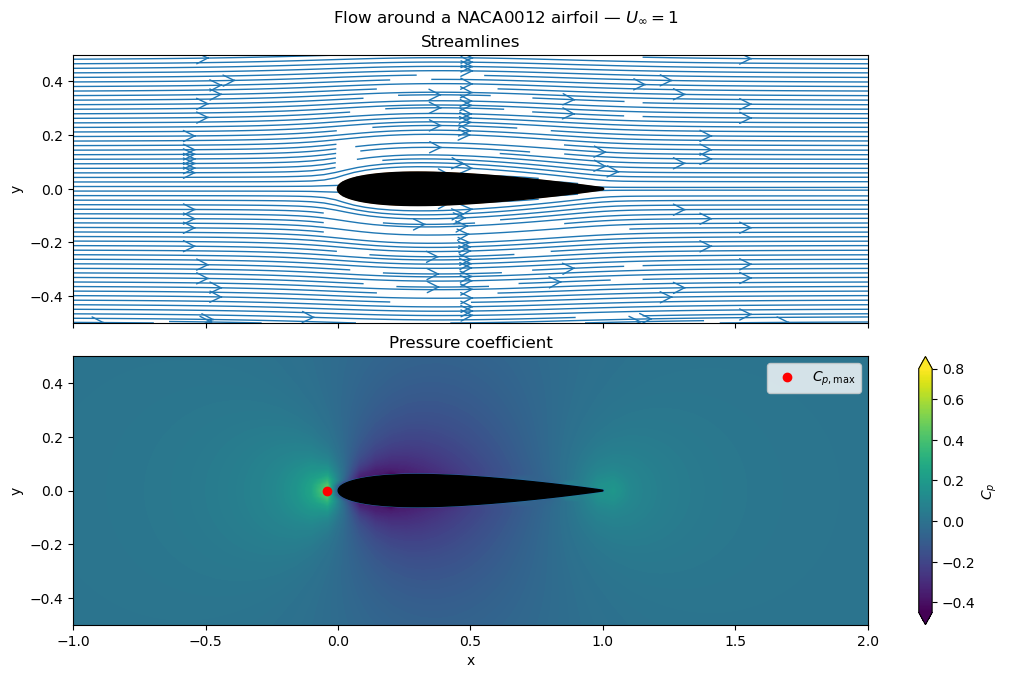

In [9]:

width = 10.0
height = (y_end - y_start) / (x_end - x_start) * width * 2.0

fig, ax = plt.subplots(2, 1, figsize=(width, height), constrained_layout=True, sharex=True)

ax[0].streamplot(grid.X, grid.Y, u, v,
                density=2, linewidth=1, arrowsize=2, arrowstyle='->')
ax[0].plot(naca0012_x, naca0012_y)
ax[0].fill(naca0012_x,
            naca0012_y,
            color='k', linestyle='solid', linewidth=2, zorder=2)
ax[0].set_xlim(x_start, x_end)
ax[0].set_ylim(y_start, y_end)
ax[0].set_ylabel('y')
ax[0].set_title('Streamlines')

ctrf = ax[1].contourf(grid.X, grid.Y, cp,
                      levels=np.linspace(-0.45, 0.75, 200), extend='both')
cbar = fig.colorbar(ctrf, label=r'$C_p$')
cbar.set_ticks([-0.4, -0.2, 0.0, 0.2, 0.4, 0.6, 0.8])
ax[1].plot(naca0012_x, naca0012_y)
ax[1].scatter(grid.X[cp_max_row, cp_max_column], grid.Y[cp_max_row, cp_max_column], 
              color='r', label=r'$C_{p,\max}$', zorder=3)
ax[1].fill(naca0012_x, naca0012_y, color='k', zorder=2)
ax[1].legend()
ax[1].set_xlim(x_start, x_end)
ax[1].set_ylim(y_start, y_end)
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
ax[1].set_title('Pressure coefficient')

fig.suptitle(rf'Flow around a NACA0012 airfoil — $U_\infty = {u_inf:.3g}$')

plt.show()

In [10]:
print(
    f'Maximum Cp value: {cp_max:.3g}\n'
    f'Maximum Cp row: {cp_max_row} and column: {cp_max_column}\n'
    f'Maximum Cp coordinates: '
    f'(x={grid.X[cp_max_row, cp_max_column]:.3g}, '
    f'y={grid.Y[cp_max_row, cp_max_column]:.3g})'
)

Maximum Cp value: 0.471
Maximum Cp row: 25 and column: 16
Maximum Cp coordinates: (x=-0.04, y=0)


**Before starting:**
- Point of maximum pressure: at the leading edge of the airfoil.
- That point is called the stagnation point.
- The airfoil will not generate any lift.

**Think:**
1. Yes, the streamlines look as expected: the flow is symmetric and goes smoothly around the airfoil.
2. The NACA0012 does not generate any lift: the pressure on the upper side cancels the pressure on the lower side.
3. Yes, the maximum pressure is at the stagnation point at the front of the airfoil, where the flow hits the airfoil perpendicularly. $C_{p,\max} = 0.471$ and not 1, because no grid point sits exactly on the stagnation point.